### 3D City Models from Volunteered Public Data

<div class="alert alert-block alert-warning"><b>This notebook will:</b>

> **1. produce an [interactive *pseudo-3D* Building Model visualization](#Section1)** - which a user can navigate, query, share* **that**;
> > **i) [colour buildings by type](#Section1a)** *(to easily visualize building stock)*  
> > **ii) [includes additional features](#Section1b)** *(parks, bus rapid transit route, etc.)*  
>
> **2. allow the user to execute an application of Spatial Data Science**  
>
>> **i)  [population estimation](#Section2a)** _--with a previous census metric population growth rate and projected (future) population are also possible_  **and**    
>> **ii)  a measure of [Building Volume per Capita](#Section2b).**
>
> **3. further applications of Spatial Data Science**  
>
>> **-  calculate percentage homes and population with direct access to on-site renewable energy infrastructure** *--rooftop photovoltaic panels (PV) and solar water heaters (SWH).*
>> 
>> **- estimate the [Annual Average Solar *(photovoltaic)* Potential](https://www.worldbank.org/en/topic/energy/publication/solar-photovoltaic-power-potential-by-country), per home.**
>
> **4. propose several [Geography and Sustainable Development Education *conversation starters*](#Section3) for Secondary and Tertiary level students** 

</div>

<div class="alert alert-block alert-danger"><b>Please Note:</b>

***The [village](https://github.com/AdrianKriger/geo3D/tree/main/village)*** processing option is meant for areas with no more than for **2 500 buildings**.</div>

In [1]:
#load the magic
import time
from datetime import timedelta

%matplotlib inline
import os
import sys
from pathlib import Path
import requests

import overpass
import numpy as np
import pandas as pd
import shapely
from shapely.geometry import Point, LineString, Polygon, MultiPolygon, shape, mapping
from shapely.strtree import STRtree

import json
import fiona
import geojson

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

In [2]:
#- get current working directory (notebook location)
current_dir = os.getcwd()

#- go one level up
parent_dir = os.path.dirname(current_dir)
# Add parent directory to sys.path if needed
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

#- import
import city3D

In [3]:
import warnings
Tstart = time.time()
warnings.filterwarnings('ignore')

<a id='Section1'></a>

## 1. Interactive Visualization

**Harvest [OpenStreetMap](https://en.wikipedia.org/wiki/OpenStreetMap)** - Query the [Overpass API](https://wiki.openstreetmap.org/wiki/Overpass_API) from within Jupyter and convert to .geojson.

<div class="alert alert-block alert-info"><b>Set an area-of-interest:</b> 
    
This is done: `large` area -> `focus` area or State (Province) -> Village (neighourhood / campus)
</div>

In [4]:
large = 'Western Cape'
focus = 'Mamre'                  # | 'University Estate' | 'Cape Peninsula University of Technology (Bellville Campus)' | 'Salt River'
osm_type = 'relation'

In [5]:
query = """
     [out:json][timeout:360];
    // --when areas have duplicate names given the world has a limited amount of uniquely named places
    area[name='{0}'] ->.b;
    // -- target area ~ can be way or relation
    wr(area.b)[name='{1}'];
    map_to_area -> .a;
        // I want all buildings
        (way['building'](area.a);
        // and relation type=multipolygon ~ to removed courtyards from buildings
        relation["building"]["type"="multipolygon"](area.a);
    );
    out count;
    out geom 2500;
    //out body;
    //>;
    //out skel qt;
    """.format(large, focus)

<div class="alert alert-block alert-danger"><b>NOTICE:</b>

***[village](https://github.com/AdrianKriger/geo3D/tree/main/village)*** will return a maximum of 2 500 buildings in any `focus` area.</div>

In [6]:
#- execute function from city3D and harvest buildings
gdf = city3D.overpass_to_gdf(query)
gdf.head(2)

,building,building:levels,addr:city,addr:postcode,addr:street,addr:suburb,amenity,denomination,diocese,heritage,...,street_vendor,brand,opening_date,self_service,capacity,construction,type,geometry,osm_id,osm_type
0,yes,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((18.4706033 -33.5057876, 18.4706995 -...",328118446,way
1,church,2,Cape Town,7347,Kerk Street,Mamre,place_of_worship,moravian,Cape Town North,building,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((18.4709153 -33.5059178, 18.4709287 -...",328118447,way


In [7]:
#- some print statements
print('')
print(focus, 'has', len(gdf), 'buildings')
if int(len(gdf)) < 2500:
    print('\n\033[1mAll the buildings\033[0m  in', focus, 'have been harvested')
else:
    print('\n', int(len(gdf))-2500, "buildings have not been harvested.")

#-- try focus = 'Salt River' to see how a small urban suburb will perform or go over to the Suburb folder


Mamre has 2372 buildings

All the buildings  in Mamre have been harvested


<div class="alert alert-block alert-info"><b></b>


Please do not burden the [OpenStreetMap](https://www.openstreetmap.org/about) server with excessive calls for data.

**If you need to investigate a larger area (> 2 500 buildings); choose *[suburb](https://github.com/AdrianKriger/geo3D/tree/main/suburb)* please.**</div>

<div class="alert alert-block alert-warning"><b>Calculate building height:</b> 

We assume a building level is 2.8 meters high and add another 1.3 meters (to account for the roof) and create a new attribute `height`.</div>

The Python code to execute the `.process_and_write_geojson` function is in the `city3D.py` script

In [8]:
# -- execute function. calculate building height
#gdf = city3D.process_and_write_geojson(gdf)
gdf = city3D.bldHeights(gdf)
gdf.head(2)

,osm_id,address,building,building:levels,building:use,residential,amenity,operator,building_height,min_height,plus_code,footprint,geometry
0,328118446,None,yes,1,NaN,NaN,NaN,NaN,4.1,0.0,4FRWFFVC+P79,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4706033 -33.5057876, 18.4706995 -..."
1,328118447,Moravian Church South Africa Kerk Street Mamre...,church,2,NaN,NaN,place_of_worship,NaN,6.9,0.0,4FRWFFVC+H9Q,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4709153 -33.5059178, 18.4709287 -..."


In [9]:
#read into .gpd

#- get the location for pydeck. combine all geometries
geom = shapely.unary_union(gdf['geometry'])
# centroid
xy = (geom.centroid.x, geom.centroid.y)

# bounding box
#minx, miny, maxx, maxy = geom.bounds
#bbox = [minx, miny, maxx, maxy]

***~ In order to make the most of the semantic data we need to extract the `osm_tags` from the dictionary: and add it as `tooltips` to the visualization.***

<a id='Section1a'></a>
<div class="alert alert-block alert-success"><b>Building Stock:</b> To differentiate a school, formal and informal housing, retail, healthcare and community focused facilities (library, municipal office, community centre) we color the buildings - we harvest the osm tags [building type] directly.</div>

In [10]:
#- look
build_df = gdf.copy()
build_df.head(2)

,osm_id,address,building,building:levels,building:use,residential,amenity,operator,building_height,min_height,plus_code,footprint,geometry
0,328118446,None,yes,1,NaN,NaN,NaN,NaN,4.1,0.0,4FRWFFVC+P79,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4706033 -33.5057876, 18.4706995 -..."
1,328118447,Moravian Church South Africa Kerk Street Mamre...,church,2,NaN,NaN,place_of_worship,NaN,6.9,0.0,4FRWFFVC+H9Q,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4709153 -33.5059178, 18.4709287 -..."


In [11]:
# have a look at the building type and amenities available
build_df['building'].unique()

array(['yes', 'church', 'house', 'cabin', 'public', 'civic', 'office',
       'retail', 'clinic', 'school', 'garage', 'greenhouse', 'roof',
       'kindergarten', 'construction', 'clubhouse', 'guest_house',
       'service', 'detached', 'shed'], dtype=object)

In [12]:
#- number buildings
len(build_df)

2344

In [13]:
#- some data wrangling to account for when building:use is different from the original purpose 
#- (building=warehouse now loft apartments or =church now office, etc.)
df2 = build_df.copy()

# The entire operation is a single line using .loc
df2.loc[
    # The condition to find rows where 'building:use' is 'residential'
    # This check ensures the column exists, preventing a KeyError
    (df2['building:use'] == 'residential') & ~df2['building:use'].isna() 
    if 'building:use' in df2.columns else [False] * len(df2), 
    
    # The column to be updated
    'building'] = (
    # The value to assign to the 'building' column
    df2['building:use'] 
    if 'building:use' in df2.columns else None
)

In [14]:
# colour buildings based on use / amenity
def color(bld):
    #- formal house
    if bld == 'house' or bld == 'semidetached_house' or bld == 'terrace': #- add maisonette, duplex, etc. 
        return [255, 255, 204]                        #-grey
    if bld == 'apartments':
        return [252, 194, 3]                          #-orange 
    #- informal structure / social housing / student
    if bld == 'residential' or bld == 'dormitory' or bld == 'cabin':
        return [119, 3, 252]                          #-purple
        
    if bld == 'garage' or bld == 'parking':
        return [3, 132, 252]                          #-blue        
    if bld == 'retail' or bld == 'supermarket':
        return [253, 141, 60]
    if bld == 'office' or bld == 'commercial':
        return [185, 206, 37]
    if bld == 'school' or bld == 'kindergarten' or bld == 'university' or bld == 'college':
        return [128, 0, 38]
    if bld == 'clinic' or bld == 'doctors' or bld == 'hospital':
        return [89, 182, 178]
    if bld == 'community_centre' or bld == 'service' or bld == 'post_office' or bld == 'hall' or bld == 'civic' \
    or bld ==  'townhall' or bld == 'police' or bld == 'library' or bld == 'fire_station' :
        return [181, 182, 89]
    if bld == 'warehouse' or bld == 'industrial':
        return [193, 255, 193]
    if bld == 'hotel':
        return [139, 117, 0]
    if bld == 'church' or bld == 'mosque' or bld == 'synagogue':
        return [225, 225, 51]
    else:
        return [255, 255, 204]

#build_df["fill_color"] = build_df['combine'].apply(lambda x: color(x))
df2["fill_color"] = df2['building'].apply(lambda x: color(x))

In [15]:
df2.head(2)
#build_df.coordinates[0]

,osm_id,address,building,building:levels,building:use,residential,amenity,operator,building_height,min_height,plus_code,footprint,geometry,fill_color
0,328118446,None,yes,1,NaN,NaN,NaN,NaN,4.1,0.0,4FRWFFVC+P79,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4706033 -33.5057876, 18.4706995 -...","[255, 255, 204]"
1,328118447,Moravian Church South Africa Kerk Street Mamre...,church,2,NaN,NaN,place_of_worship,NaN,6.9,0.0,4FRWFFVC+H9Q,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4709153 -33.5059178, 18.4709287 -...","[225, 225, 51]"


<a id='Section1b'></a>
<div class="alert alert-block alert-success"><b>Additional Features:</b> 
    
To show the potential and power of **3D City Models** we can add additional features to the visualization; *namely: bus rapid transit, parks, agricultural land and waterways (streams). We get this from [OpenStreetMap](https://en.wikipedia.org/wiki/OpenStreetMap) as well.*.</div>

In [19]:
query = """[out:json][timeout:360];
            // --main area
            area[name='{0}']->.b;
            // -- target area ~ can be way or relation
            wr(area.b)[name='{1}'];
            map_to_area -> .a;
                (
                // query
                //way["sport"](area.a);
                way[leisure~'track|pitch|park'](area.a);
                // relations (multipolygons)
                relation["leisure"~"track|pitch|park"](area.a);
                );
           // print results
           out geom;
           """.format(large, focus)

green_spaces = city3D.overpass_to_gdf(query)#, geojson=True)

In [22]:
query = """[out:json][timeout:360];
            // --main area
            area[name='{0}']->.b;
            // -- target area ~ can be way or relation
            wr(area.b)[name='{1}'];
            map_to_area -> .a;
                (
                // query
                way['waterway'='stream'](area.a);
                way['water'](area.a);
                );
            // print results
            out geom;
            """.format(large, focus)

water_spaces = city3D.overpass_to_gdf(query)#, geojson=True)

#query = """[out:json][timeout:180];
#        // --main area
#        area[name='{0}']->.b;
#        // -- target area ~ can be way or relation
#        wr(area.b)[name='{1}'];
#        map_to_area -> .a;
#            (
#            // query
#            way['landuse'='farmland'](area.a);
#            );
#        // print results
#        out geom;
#        """.format(large, focus)
#
#p_spaces = city3D.overpass_to_gdf(query, geojson=True)

In [26]:
# the bus route ~~ note we only choose routes with a 'colour' tag
query = """[out:json][timeout:360];
        area[name='{0}'];
        // -- target area ~ can be way or relation
        // gather results
        (
        // query part for: “"bus route"”
        relation["type"="route"]["route"="bus"]['operator'="MyCiTi"]['colour'](area);
        );
        // print results
        out geom;""".format(large)

Rgdf = city3D.overpass_to_gdf(query)

In [27]:
# look
Rgdf.head(2)

,colour,from,name,network,operator,public_transport:version,ref,route,to,type,...,fee,interval,opening_hours,direction,note,website,description,geometry,osm_id,osm_type
0,#AACDD2,Civic Centre,Bus A01: Civic Centre – Airport [Suspended],Cape Town IRT,MyCiTi,2,A01,bus,Airport,route,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (18.4287357 -33.9197677, 18.4288394...",947075,relation
1,#AACDD2,Airport,Bus A01: Airport – Civic Centre [Suspended],Cape Town IRT,MyCiTi,2,A01,bus,Civic Centre,route,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (18.5958488 -33.9695727, 18.59574 -...",947076,relation


In [28]:
# extract path and assign colour ~~ so the visualization matches the official documentation

Rgdf = Rgdf[Rgdf['colour'].notna()]

def hex_to_rgb(h):
    h = h.lstrip("#")
    #h = h.replace('#', '')
    return tuple(int(h[i : i + 2], 16) for i in (0, 2, 4))

Rgdf["colour"] = Rgdf["colour"].apply(hex_to_rgb)

Rgdf.head(2)

,colour,from,name,network,operator,public_transport:version,ref,route,to,type,...,fee,interval,opening_hours,direction,note,website,description,geometry,osm_id,osm_type
0,"(170, 205, 210)",Civic Centre,Bus A01: Civic Centre – Airport [Suspended],Cape Town IRT,MyCiTi,2,A01,bus,Airport,route,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (18.4287357 -33.9197677, 18.4288394...",947075,relation
1,"(170, 205, 210)",Airport,Bus A01: Airport – Civic Centre [Suspended],Cape Town IRT,MyCiTi,2,A01,bus,Civic Centre,route,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (18.5958488 -33.9695727, 18.59574 -...",947076,relation


In [29]:
#green_spaces

In [30]:
#- create pseudo-3D viz

file = '../result/interactiveOnly.html' # will name and save html here

html = city3D.create_maplibre_3Dviz(
    result_dir = file, 
    buildings_gdf = df2,
    water_gdf = water_spaces,
    green_gdf = green_spaces,
    brt_gdf = Rgdf,
    center = xy
)

city3D.show_interactive_html(html)

**on a laptop without a mouse:**

- `trackpad left-click drag-left` and `-right`;
- `Ctrl left-click drag-up`, `-down`, `-left` and `-right` to rotate and so-on and
- `+` next to Backspace zoom-in and `-` next to `+` zoom-out.

**Now you do your community.** ~ If your area needs [OpenStreetMap](https://en.wikipedia.org/wiki/OpenStreetMap)  data and you want to contribute please follow the [Guide](https://wiki.openstreetmap.org/wiki/Beginners%27_guide).

***

<div class="alert alert-block alert-danger"><b>GO FURTHER</b></div>

## 2. Spatial Data Science

<div class="alert alert-block alert-warning"><b>Now that we have a visualization of building stock (buildings colorized by `use`); lets do some basic spatial analysis:</b>  
    
     
- We'll estimate the population, within our area of interest, and then  
- calculate the Building Volume Per Capita (BVPC).
</div>

While estimating population is well documented; recent investigations to **understand overcrowding** have led to newer measurements.  

The most noteable of these is **Building Volume Per Capita (BVPC)** [(Ghosh, T; et al. 2020)](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs). BVPC is the cubic meters of building per person. **BVPC tells us how much space one person has per residential living unit** (a house / apartment / etc.). It is ***a proxy measure of economic inequality and a direct measure of housing inequality***. 

BVPC builds on the work of [(Reddy, A and Leslie, T.F., 2013)](https://www.tandfonline.com/doi/abs/10.1080/02723638.2015.1060696?journalCode=rurb20) and attempts to integrate with several **[Sustainable Development Goals](https://sdgs.un.org/goals)** (most noteably: **[SDG 11: Developing sustainable cities and communities](https://sdgs.un.org/goals/goal11)**) and captures the average ***'living space'*** each person has in their home.

<div class="alert alert-block alert-info"><b>These analysis expect the user to have some basic knowledge about the environment under inquiry / investigation</b> </div>

In [31]:
#-- lets have a look at the data we have
df2.head(2)

,osm_id,address,building,building:levels,building:use,residential,amenity,operator,building_height,min_height,plus_code,footprint,geometry,fill_color
0,328118446,None,yes,1,NaN,NaN,NaN,NaN,4.1,0.0,4FRWFFVC+P79,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4706033 -33.5057876, 18.4706995 -...","[255, 255, 204]"
1,328118447,Moravian Church South Africa Kerk Street Mamre...,church,2,NaN,NaN,place_of_worship,NaN,6.9,0.0,4FRWFFVC+H9Q,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4709153 -33.5059178, 18.4709287 -...","[225, 225, 51]"


In [32]:
#--we only want building=house or =apartment or =residential
#gdf.head(2)

<a id='Section2a'></a>

<div class="alert alert-block alert-success"><b>2.  a) Estimate Population:</b> 
    
_(with population growth rate and population projection possible too)_ </div>

In [33]:
#- some data wrangling to replace 'bld:residential' to 'bld:student' if 'residential:student'
gdf2 = df2.copy()

gdf2.loc[
    # The condition to find rows where 'residential' is 'student'
    # This check ensures the column exists, preventing a KeyError
    (gdf2['residential'] == 'student') & ~gdf2['residential'].isna() 
    if 'residential' in gdf2.columns else [False] * len(gdf2), 
    
    # The column to be updated
    'building'] = (
    # The value to assign to the 'building' column
    gdf2['residential'] 
    if 'residential' in gdf2.columns else None
)

#- some more data wrangling - Convert numeric columns
with pd.option_context("future.no_silent_downcasting", True):
    gdf2 = gdf2.assign(**{
        col: pd.to_numeric(
            gdf2[col].fillna(0).infer_objects(copy=False), errors='coerce'
        )
        for col in ['building:flats', 'building:units', 'beds', 'rooms', 'building:levels']
        if col in gdf2.columns
    })

print(len(gdf2))

2344


In [34]:
gdf2.head(2)

,osm_id,address,building,building:levels,building:use,residential,amenity,operator,building_height,min_height,plus_code,footprint,geometry,fill_color
0,328118446,None,yes,1,NaN,NaN,NaN,NaN,4.1,0.0,4FRWFFVC+P79,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4706033 -33.5057876, 18.4706995 -...","[255, 255, 204]"
1,328118447,Moravian Church South Africa Kerk Street Mamre...,church,2,NaN,NaN,place_of_worship,NaN,6.9,0.0,4FRWFFVC+H9Q,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((18.4709153 -33.5059178, 18.4709287 -...","[225, 225, 51]"


In [35]:
#- 
gdf2['building'].value_counts()

building
house           1642
cabin            382
yes              157
garage           116
retail            11
civic              7
roof               7
school             5
church             3
public             2
construction       2
detached           2
office             1
clinic             1
greenhouse         1
kindergarten       1
clubhouse          1
guest_house        1
service            1
shed               1
Name: count, dtype: int64

**This area is urban with single level housing units. To estimate population is thus pretty straight forward.**

<div class="alert alert-block alert-info"><b>We start with local knowledge.</b></div>

**On average there are roughly `6` people per `building:house` in this area.**  

An ***informal*** structure ([shack](https://en.wikipedia.org/wiki/Shack)) is tagged [building:cabin](https://wiki.openstreetmap.org/wiki/Tag:building%3Dcabin) and houses `4` people.

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
We will execute the calculation programmatically. **Fill in the relevant variables in the _`cell`_ below** </div>

In [36]:
#- average number of residents per formal house
f_house = 6
#- average number of residents per informal structure
inf_structure = 4

<div class="alert alert-block alert-warning"><b></b>  
    
**Furthermore:**  
    - **[social housing](https://en.wikipedia.org/wiki/Public_housing)** is tagged `building:residential` with the number of occupants iether *the number of informal structure occupants* or `building:flats * inf_structure`  
    - A `social_facility` (carehome, shelter, etc.) harvests the `beds` *'key:value'* pair.  
    - `building:apartments` harvests the `building:flats` *'key:value'* pair *(the number of units)* to calculate `*3` people per apartment.  
    - ***Student accomodation***:  
>    - University owed: is tagged `building:dormitory` with `residential:university` and harvests the `beds` *'key:value'* pair.
>    - Private for-profit: is tagged `building:residential` or `:dormitory` with `residential:student` and then harvests the `building:flats` or `:rooms` *'key:value'* pair *(the number of units)* to calculate `*1` people per apartment; if `level: > 1` else `*3` people in a house share.
    
**The tagging scheme and numbers is based on *how your community is mapped* and local knowledge**
</div>

In [37]:
c = gdf2.columns

def pop(row):
    #- formal house
    if row['building'] == 'house' or row['building'] == 'semidetached_house':
        return f_house
    if row['building'] == 'terrace' or row['building'] == 'terraced':
        if 'building:units' in c and row['building:units'] != 0:
            return row['building:units'] * f_house
        else:
            f_house

    #- informal structure (shack)
    if row['building'] == 'cabin':
        return inf_structure
        
    #- in this case social housing
    if row['building'] == 'residential' and row['social_facility'] is np.nan:#None:# or row['building:use'] == 'residential':
        if row['building:levels'] > 1 and 'rooms' in c and row['rooms'] != 0:
            return row['rooms']
        if row['building:levels'] > 1 and 'building:flats' in c and row['building:flats'] != 0:
            return row['building:flats'] * inf_structure
        else:
            return inf_structure

    #-- social facility [shelter / carehome]
    if row['building'] == 'residential' and row['social_facility'] is not np.nan: #!= None:
        if row['building:levels'] > 1:
            if 'building:units' in c and row['building:units'] != 0:
                return row['building:units'] * inf_structure
            else: 
                return row['beds']
        else:
            return inf_structure
            
    #- formal apartment
    if row['building'] == 'apartments':
        if 'rooms' in c and row['rooms'] != 0:
            return row['rooms']
        else:
            return int(row['building:flats']) * 3
        
    #- private student residence
    if row['building'] == 'student': 
        if row['building:levels'] > 1:
            if 'rooms' in c and row['rooms'] != 0:
                return row['rooms']
            else:
                return row['building:flats']
        else:
            return 3
    # university owned student residence
    if row['building'] == 'dormitory' and row['residential'] == 'university':
        if row['building:levels'] > 1:
            if 'rooms' in c and row['rooms'] != 0:
                return row['rooms']
            if 'beds' in c and row['beds'] != 0:
                return row['beds']
        else:
            return 3

gdf2['pop'] = gdf2.apply(lambda x: pop(x), axis=1)

est_pop = gdf2['pop'].sum()
print('The estimated population is:', est_pop)

The estimated population is: 11380.0


**The official [STATSSA 2011 census figure](https://www.statssa.gov.za/?page_id=4286&id=291), for this community, is 9048.**

We can calculate the annual population growth rate using the formula for **[Annual population growth](https://databank.worldbank.org/metadataglossary/health-nutrition-and-population-statistics/series/SP.POP.GROW):**

$$r = \frac{\ln{[\frac{End Population}{Start Population}}]}{n} * 100 = \frac{\ln{[\frac{11 120^{*}}{9048}}]}{12} * 100   = 1.47 \%$$
<br>
<sup>* <sub>***Notice!*** The estimated population (11176) is **NOT** the number in the formula (11 120). This community is frequently updated on OpenStreetMap and variations are common.</sub> 

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    

It is possible to execute the calculation programmatically. **Fill in the relevant variables in the _`cell`_ below** </div>

In [38]:
#- previous population
start_population = 9048 

#- period in years from the previous census
years = 14

In [39]:
#-execute
r = (np.log(est_pop/start_population)/years) * 100
print('population growth rate of approximately:', round(r, 2), '%')

population growth rate of approximately: 1.64 %


To conclude; we can project into the future with a very basic formula to estimate the population _x_-years from now:  

$$p  = P_o * (1 + r)^{t} = p = 10736 * (1 + 0.0143)^{10}  = 12 368$$

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
It is possible to execute the calculation programmatically. **Fill in the variables in the _`cell`_ below** </div>

In [40]:
#- period in years from now
years = 10

In [41]:
#p = est_pop * (1 + (r/100))**years
#print('estimated population', years ,'years from now:', int(p))

#- account for non-residential areas without failure
#- helper function
def safe_population_estimate(est_pop, r, years):
    try:
        p = est_pop * (1 + (r / 100))**years
        return int(p)
    except Exception as e:
        print(f"Population estimate failed: {e}")
        return None  # keeps notebook running

#- execute function
p = safe_population_estimate(est_pop, r, years)

#- shows error and moves on
if p is not None:
    print(f"estimated population {years} years from now: {p}")

estimated population 10 years from now: 13387


<a id='Section2b'></a>

<div class="alert alert-block alert-success"><b>2. ii) Building Volume Per Capita (BVPC):</b></div>

**We first need to check the quality** *---topology---* **of the dataset**

In [42]:
gdf2.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<img src="../data/proj.png" alt="proj" width="550" align="right"/>

<br>
<br>

**We also need [BVPC](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs) in a cubic meter but our data is in Decimal Degrees.**  

We need to convert coordinates from a ***Geographic*** to a local ***Projected*** system.  

<div class="alert alert-block alert-info"><b>To keep this extremely generic (use anywhere) we go with WGS84 / Universal Transverse Mercator (UTM).</b></div>

In [43]:
#- internal geopandas function
gdf2.estimate_utm_crs()  

<Projected CRS: EPSG:32734>
Name: WGS 84 / UTM zone 34S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 18°E and 24°E, southern hemisphere between 80°S and equator, onshore and offshore. Angola. Botswana. Democratic Republic of the Congo (Zaire). Namibia. South Africa. Zambia.
- bounds: (18.0, -80.0, 24.0, 0.0)
Coordinate Operation:
- name: UTM zone 34S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
**Fill in the proper `epsg` in the _`cell`_ below** 
</div>

In [44]:
#- first line above: <Projected CRS: EPSG:xxxxx>
epsg = 32734

In [45]:
#- highlight crossing features (buildings). more buildings = more time
start = time.time()

gdf2 = gdf2.to_crs(epsg)
gdf_copy = gdf2.copy()

geoms = gdf_copy["geometry"].tolist()
tree = STRtree(geoms)

#- remove self matches and select overlapping geometries
#left_idx = joined["index_left"]
#right_idx = joined["index_right"]
#mask = left_idx != right_idx
#overlap_idx = left_idx[mask].unique()

#- Query the tree for overlaps
# This returns two arrays: 'i' (index in geoms we are checking) and 'j' (index in the tree it overlapped with)
# Vectorized query: fastest way to find overlaps
i, j = tree.query(geoms, predicate="overlaps")

#- filter self-matches and get unique indices of all involved buildings
mask = i != j
overlap_idx = set(i[mask])

new_df1 = gdf_copy.iloc[list(overlap_idx)].reset_index(drop=True)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.245808


**Plot**

*Browse the saved `'./data/topologyFig'` at your leisure*

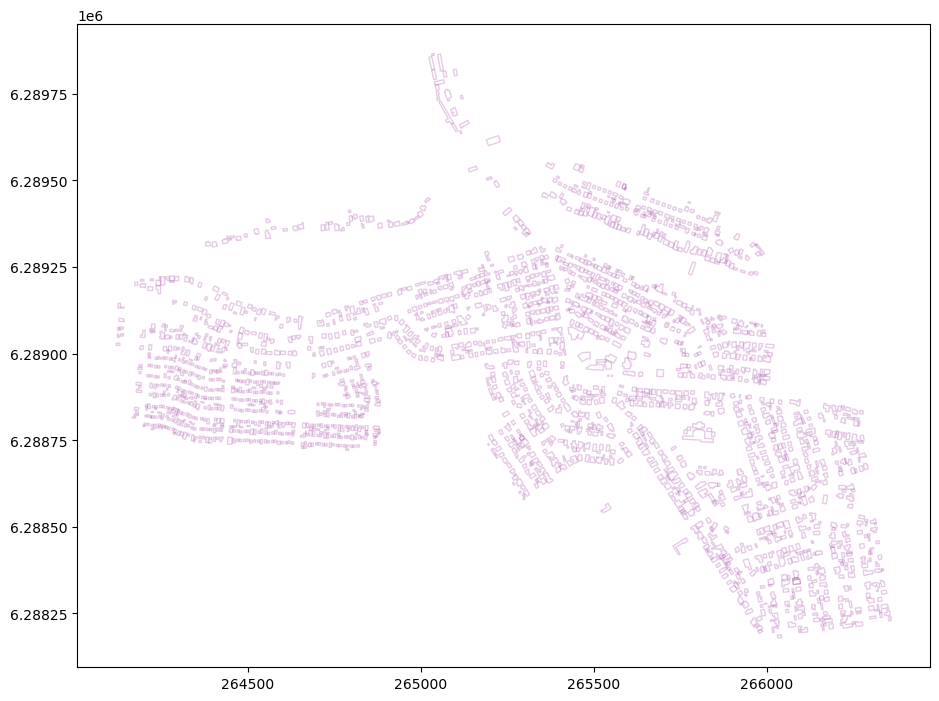

In [46]:
#-plot

def plot_geometries(df, ax=None, facecolor='none', edgecolor='purple', alpha=0.5):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,10))

    patches = []

    for geom in df['geometry']:
        if geom is None:
            continue

        if isinstance(geom, Polygon):
            # Exterior ring
            patches.append(MplPolygon(list(geom.exterior.coords), closed=True))
            # Interiors (holes)
            for interior in geom.interiors:
                patches.append(MplPolygon(list(interior.coords), closed=True))
        elif isinstance(geom, MultiPolygon):
            for poly in geom.geoms:
                patches.append(MplPolygon(list(poly.exterior.coords), closed=True))
                for interior in poly.interiors:
                    patches.append(MplPolygon(list(interior.coords), closed=True))

    pc = PatchCollection(patches, facecolor=facecolor, edgecolor=edgecolor, alpha=alpha)
    ax.add_collection(pc)
    ax.autoscale()
    ax.set_aspect('equal')
    return ax

# Example usage:
fig, ax = plt.subplots(figsize=(11, 11))
plot_geometries(gdf_copy, ax=ax, facecolor='none', edgecolor='purple', alpha=0.2)
if len(new_df1) > 0:
    plot_geometries(new_df1, ax=ax, facecolor='none', edgecolor='red', alpha=0.5)
#-- save
plt.savefig('../data/topologyFig', dpi=300)
#plt.show()

|  |  |
|:--------:|:--------:|
| 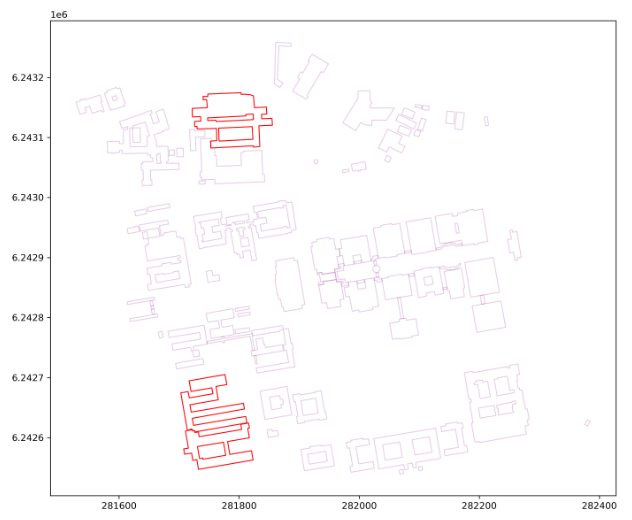| **Challenges will be highlight in *'Red'***|
| 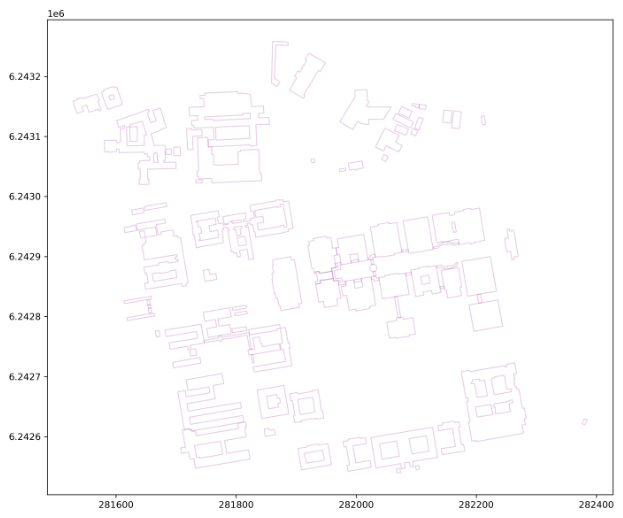| **or none**|

<h2><center> If you continue without fixing the challenges, the BVPC value will not be true.  <br /><br /> Our goal is to be as representative as possible. </center></h2>

**If necessary; edit [OpenStreetMap](https://www.openstreetmap.org/about) and fix the challenge please.** 

<div class="alert alert-block alert-warning"><b>  </b> 

And remember to give the OpenStreetMap server at least a day before attempting the process again.
    
**Alchemy is a process. Please be patient.**
</div>

<div class="alert alert-block alert-success"><b>BVPC = total population of a community divided by sum of building volume</b></div>

In [47]:
#- area and volume
gdf2['area'] = gdf2['geometry'].apply(lambda geom: geom.area if geom else 0)
gdf2['volume'] = gdf2['area'] * gdf2['building_height']

#- remove the volume of the ground floor (unoccupied) when building:levels > 7 [this is an arbitrary number based on local knowledge]
#- typically this space is reserved for some other function: retail, etc. 
gdf2['volume'] = [
    (row['volume'] - row['area'] * 2.8) if (
        ('social_facility' not in gdf2.columns or pd.isna(row.get('social_facility')))
        and row['building:levels'] > 7
        and row['building'] in ['residential', 'apartments', 'student']
    ) else row['volume']
    for _, row in gdf2.iterrows()
]
 
gdf2['bvpc'] = np.where(
    gdf2['pop'] > 0,
    gdf2['volume'] / gdf2['pop'],
    np.nan
)
gdf2.tail(2)

,osm_id,address,building,building:levels,building:use,residential,amenity,operator,building_height,min_height,plus_code,footprint,geometry,fill_color,pop,area,volume,bvpc
2369,12289266,22 Clarkeson Street Mamre 7347 Cape Town,house,1,NaN,NaN,NaN,NaN,4.1,0.0,4FRWFFMF+W7J,"[[(18.473, -33.515), (18.473, -33.515), (18.47...","POLYGON ((265302.8715881496 6288753.930217357,...","[255, 255, 204]",6.0,344.679759,1413.187012,235.531169
2370,12357148,2 Tol Street Mamre 7347 Cape Town,house,1,NaN,NaN,NaN,NaN,4.1,0.0,4FRWFFPJ+P7W,"[[(18.481, -33.513), (18.481, -33.513), (18.48...","POLYGON ((265989.6485932828 6288995.734908563,...","[255, 255, 204]",6.0,327.808101,1344.013215,224.002202


In [48]:
print(gdf2['bvpc'].describe())

count    2024.000000
mean       74.937556
std        49.834958
min         7.419412
25%        32.781743
50%        65.428197
75%       101.510961
max       399.892663
Name: bvpc, dtype: float64


In [49]:
bvpc = round(gdf2['volume'].sum() / est_pop, 3)

print('Building Volume Per Capita (BVPC):', bvpc)

Building Volume Per Capita (BVPC): 89.588


<div class="alert alert-block alert-info"><b></b>

**This BVPC value is for all buildings with a `population > 0`. Buildings people live in** *(homes)*. 

And we can seperate `building:house` from `building:cabin` and `building:residential` to undertand the differences between ***formal and informal*** housing in this area.
    
**We want to understand the living space *(the cubic-meter BVPC value)* each person has in thier home**
</div>

In [50]:
formal = gdf2[gdf2["building"].isin(['house', 'semidetached_house', 'terrace', 'terraced', 'apartment'])].copy()
f_pop = formal['pop'].sum()

informal = gdf2[gdf2["building"].isin(['residential', 'cabin'])].copy()
inf_pop = informal['pop'].sum()

#- student
stu = gdf2[gdf2["building"].isin(['student', 'dormitory'])].copy()
stu_pop = stu['pop'].sum()

bvpc_formal = round(formal['volume'].sum() / formal['pop'].sum() if formal['pop'].sum() != 0 else 0, 3)
bvpc_informal = round(informal['volume'].sum() / informal['pop'].sum() if informal['pop'].sum() != 0 else 0, 3)
bvpc_stu = round(stu['volume'].sum() / stu['pop'].sum() if stu['pop'].sum() != 0 else 0, 3)

print('FORMAL: Population: ', f_pop, ' with Building Volume Per Capita (BVPC):', bvpc_formal)
print('')
print('STUDENT RESIDENCE: Population: ', stu_pop, ' with Building Volume Per Capita (BVPC):', bvpc_stu)
print('')
print('INFORMAL: Population: ', inf_pop, ' with Building Volume Per Capita (BVPC)', bvpc_informal)

FORMAL: Population:  9852.0  with Building Volume Per Capita (BVPC): 83.837

STUDENT RESIDENCE: Population:  0.0  with Building Volume Per Capita (BVPC): 0

INFORMAL: Population:  1528.0  with Building Volume Per Capita (BVPC) 36.682


<div class="alert alert-block alert-danger"><b>Warning: </b>
    

These are LoD1 3D City Models and works well in these types of areas.  
LoD2 would offer a more representative BVpC [(Ghosh, T; et al. 2020)](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs) value; when the complexity of the built environment increases.  

Think about a `house` with living space in the roof structure, so called *'attic living'*, or an `apartment` / `residential` building with different levels, loft apartments and/or units in the turrets of a building. 

***consider***: this area seperates [building:cabin](https://wiki.openstreetmap.org/wiki/Tag:building%3Dcabin) from `building:residential` to more precisely represent informal structures without typical roof trussess but account for [social housing](https://en.wikipedia.org/wiki/Public_housing) that does</div>

<div class="alert alert-block alert-info"><b></b>

Have a look at [**LoD2geo3D**](https://github.com/AdrianKriger/LoD2geo3D); to understand the performance of LoD2 models within the ***geo3D*** framework.
</div>

## 3. Further examples of Spatial Data Science *(renewable energy)*:

<div class="alert alert-block alert-warning"><b></b>

**Let's attempt to understand** 

- the **% of homes ***and*** population** served with renewable energy 
- the theoretical maximum electricity **(MWh) that building roofs can harvest** from the sun over the course of one year.
</div>
    
[**SDG**](https://sdgs.un.org/goals) indicators are typically calculated at **region and national scales**.  
Here, because we are working with highly detailed, local data, we can explore what a [**Tier 3 local indicator**](https://unstats.un.org/sdgs/metadata/) might look like at a ***neighbourhood level***.
<br>

In this section 3. we evaluate [**SDG 7: Ensure access to affordable, reliable, sustainable and modern energy for all**](https://sdgs.un.org/goals/goal7) at a community level and estimate the **proportion of residential units and population** that have **direct access to on-site renewable energy infrastructure** *--rooftop photovoltaic panels (PV) and solar water heaters (SWH)*.

> **a**. Percentage of **households** served by rooftop renewable energy  
> **b**. Percentage of the **population** served by rooftop renewable energy  
> **c**. And then we go even further to estimate the **Annual Solar Potential in MWh** *(theoretical maximum electricity)* that homes can harvest from the sun over the course of one year.

In [56]:
#- harvest rooftop solar

query = """
     [out:json][timeout:360];
    // --when areas have duplicate names given the world has a limited amount of uniquely named places
    area[name='{0}'] ->.b;
    // -- target area ~ can be way or relation
    wr(area.b)[name='{1}'];
    map_to_area -> .a;
    (
        way["power"="generator"]["generator:source"="solar"](area.a);                // Catches simple generators
       //  way["power"="solar_photovoltaic_panel"](area.a);                          // Catches the alternate tag
    );
    out geom;
    """.format(large, focus)

#- execute function from city3D, harvest generator solar and return GeoDataFrameLite | home-baked gdf
sol = city3D.overpass_to_gdf(query)
sol = sol.to_crs(epsg)

if len(sol) < 0:
    print("\033[0m No rooftop solar are mapped in", focus)

In [57]:
#- look
sol.head(2)

,generator:method,generator:output:hot_water,generator:source,generator:type,location,power,start_date,area,generator:output:electricity,geometry,osm_id,osm_type
0,thermal,yes,solar,solar_thermal_collector,roof,generator,NaN,NaN,NaN,"POLYGON ((266074.7976815852 6288576.002370844,...",1095737675,way
1,thermal,yes,solar,solar_thermal_collector,roof,generator,NaN,NaN,NaN,POLYGON ((266194.47713799647 6288764.539267579...,1095739760,way


In [58]:
#- the number of renewable in AREA
sol['generator:method'].value_counts()

generator:method
thermal         57
photovoltaic     1
Name: count, dtype: int64

In [59]:
# join (link) rooftop renewable energy to the appropriate bld
def buildings_with_solar(gdf_buildings, gdf_solar):
    # Prepare output arrays
    solar_ids_per_building = [[] for _ in range(len(gdf_buildings["geometry"]))]
    solar_types_per_building = [[] for _ in range(len(gdf_buildings))]
    
    for i, b_geom in enumerate(gdf_buildings["geometry"]):
        for j, s_geom in enumerate(gdf_solar["geometry"]):
            #if b_geom.intersects(s_geom):
            if b_geom.contains(s_geom):
                solar_ids_per_building[i].append(gdf_solar["osm_id"].iloc[j])
                solar_types_per_building[i].append(gdf_solar["generator:method"].iloc[j])

    #- keep only unique values
    #unique_methods_per_building = [list(set(lst)) for lst in solar_types_per_building]
    
    gdf_buildings["solar_ids"] = solar_ids_per_building
    gdf_buildings["generator:method"] = solar_types_per_building #unique_methods_per_building
    gdf_buildings["has_solar"] = [len(lst) > 0 for lst in solar_ids_per_building]
    gdf_buildings["solar_ids"] = solar_ids_per_building
    
    return gdf_buildings

blds = buildings_with_solar(gdf2, sol)
blds.head(2)

,osm_id,address,building,building:levels,building:use,residential,amenity,operator,building_height,min_height,...,footprint,geometry,fill_color,pop,area,volume,bvpc,solar_ids,generator:method,has_solar
0,328118446,None,yes,1,NaN,NaN,NaN,NaN,4.1,0.0,...,"[[(18.471, -33.506), (18.471, -33.506), (18.47...",POLYGON ((265041.6351569728 6289775.0592048075...,"[255, 255, 204]",NaN,268.409550,1100.479153,NaN,[],[],False
1,328118447,Moravian Church South Africa Kerk Street Mamre...,church,2,NaN,NaN,place_of_worship,NaN,6.9,0.0,...,"[[(18.471, -33.506), (18.471, -33.506), (18.47...","POLYGON ((265070.9766813367 6289761.325392997,...","[225, 225, 51]",NaN,371.168875,2561.065235,NaN,[],[],False


In [60]:
#--we only want buildings people live in (homes). building=house or =apartment or =residential, etc.
blds = blds[blds["building"].isin(['house', 'semidetached_house', 'terrace', 'terraced', 'apartments', 'residential', 'dormitory', 'cabin', 'garage'])].copy()

### 3. a) Household rooftop solar

<div class="alert alert-block alert-success"><b>Percentage of households served by rooftop renewable energy</b></div>

$$ \text{\% homes with renewable energy} = \frac{\text{Number of dwellings with mapped solar PV or SWH}}{\text{Total number of dwellings}} \times 100 $$

In [61]:
#- harvest columns
with_solar = sum(blds["has_solar"])
pop = est_pop #gdf["pop"]
total_homes = len(blds)

solHms = round(with_solar / total_homes * 100, 2)

print(' \033[1m Percentage homes\033[0m , in', focus, ',with rooftop photovoltaic panels (PV) and solar water heaters (SWH):', solHms)

  Percentage homes , in Mamre ,with rooftop photovoltaic panels (PV) and solar water heaters (SWH): 2.62


<div style="text-align: left;"> 
<small> <b>NB:</b> this number includes the <a href="https://wiki.openstreetmap.org/wiki/Tag:building%3Dgarage">OpenStreetMap <code>building=garage</code></a> building type. Go to <code>Cell &plusmn;45</code> (above) to exclude this building type from the estimate.</small>
</div>

### 3. b) Rooftop solar population


<div class="alert alert-block alert-success"><b>Percentage of population served by rooftop renewable energy</b></div>

$$ \text{\% population with renewable energy} = \frac{\text{Number of residents with mapped solar PV or SWH}}{\text{Estimated population}} \times 100 $$

In [62]:
pop_total = blds["pop"].sum()
pop_solar = blds["pop"][blds["has_solar"]].sum()

solPop = round(pop_solar / pop_total * 100, 2)

print(' \033[1m Percentage population\033[0m , in', focus, ',with rooftop photovoltaic panels (PV) and solar water heaters (SWH):', solPop)

  Percentage population , in Mamre ,with rooftop photovoltaic panels (PV) and solar water heaters (SWH): 2.95


In [63]:
# number of solar renewable on HOMES
blds['generator:method'].explode().value_counts()

generator:method
thermal         55
photovoltaic     1
Name: count, dtype: int64

### 3. c) Solar potential (MWh)

<div class="alert alert-block alert-warning"><b></b>

In this section, we attempt to understand how much ***'fuel'*** a rooftop can get from the sun.
</div>

We are calling the [NASA POWER API (Prediction Of Worldwide Energy Resources)](https://power.larc.nasa.gov/docs/services/api/temporal/monthly/). This is a global dataset that uses [NASA satellite observations and weather models](https://power.larc.nasa.gov) to tell us exactly how much solar radiation hits a specific location on Earth.

What we are requesting:

> **Parameter:** `ALLSKY_SFC_SW_DWN` (Global Horizontal Irradiance): a 30-year historical average of solar radiation. This ensures our communities solar potential is based on ***long-term climate trends*** rather than a single year of weather.
>
> **Source:** [NASA POWER Climatology API](https://power.larc.nasa.gov/docs/services/api/temporal/climatology/)
>   
> **Goal:**
> To calculate the Annual Total GHI (kWh/m2/year). This value tells us the cumulative **'solar pressure'** hitting our rooftops over an entire year, which we then use to calculate **how many Megawatt-hours (MWh) of clean electricity our neighborhood can generate**.

In [64]:
def get_ghi_data(lat, lon):#, year="2020"):
    #url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    #url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN", # This is NASA's GHI code
        "community": "RE",                 # Renewable Energy community
        "longitude": lon,
        "latitude": lat,
        "format": "JSON"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Extract the GHI values into a list
    ghi_values = data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
    long_term_monthly = ghi_values['ANN']
    
    # CONVERSION: Multiply by 365 to get the Yearly Total Sum
    annual_total_sum = long_term_monthly * 365
    
    return annual_total_sum

lat, lon = xy[1], xy[0] 
annual_avg = get_ghi_data(lat, lon)#, year)
print(f"Annual Average GHI: {round(annual_avg, 2)} kWh/m²/year")

Annual Average GHI: 2029.76 kWh/m²/year


<div class="alert alert-block alert-success"><b>Annual Solar Potential (MWh)</b></div>

We use a simplified formula to provide a clear baseline.

$$
\text{Potential (MWh)} = \frac{(\text{Surface Area} \times \text{utilization factor}) \times \text{GHI}_{\text{annual}} \times 0.2}{1000}
$$


<div class="alert alert-block alert-warning"><b></b>

<sub>***Theoretical Framework:** The annual energy output of a photovoltaic system (E) is determined by the product of the total solar resource (GHI), the active area of the array (A), and the system's overall efficiency (η), adjusted by a Performance Ratio (PR) to account for real-world losses. — based on [NREL (2022)](https://joint-research-centre.ec.europa.eu/photovoltaic-geographical-information-system-pvgis_en) & [IEC 61724-1](https://webstore.iec.ch/en/publication/65561). We then adapt this formula and represents a combined value of 25% nominal panel efficiency and a 0.80 Performance Ratio with a **single 0.20 system efficiency value and account for usable area**, a heuristic for gabled roofs.*</sub> 
</div>

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
**Fill in the `utilization_factor` below** 
</div>

As a **'rule-of-thumb'** a community with traditional gabled houses: `utilization_factor = 0.4` *(less than half)*, while a high-density suburb with flat-roofed apartments: `utilization_factor = 0.6`

In [65]:
# on average, how much of the roof faces the sun? Adjust based on roof types
utilization_factor = 0.4  

In [66]:
# Potential (MWh) = (Area * GHI * 0.20) / 1000
blds['solar_mwh'] = ((blds['area'] * utilization_factor) * (annual_avg) * 0.20) / 1000
blds.head(2)

,osm_id,address,building,building:levels,building:use,residential,amenity,operator,building_height,min_height,...,geometry,fill_color,pop,area,volume,bvpc,solar_ids,generator:method,has_solar,solar_mwh
7,656840974,39 Dove Lane Mamre 7347 Cape Town,house,1,NaN,NaN,NaN,NaN,4.1,0.0,...,POLYGON ((264864.98193212313 6288741.008398377...,"[255, 255, 204]",6.0,38.658416,158.499506,26.416584,[],[],False,6.277400
8,656840975,37 Dove Lane Mamre 7347 Cape Town,house,1,NaN,NaN,NaN,NaN,4.1,0.0,...,"POLYGON ((264865.3504529182 6288749.140981195,...","[255, 255, 204]",6.0,39.833421,163.317028,27.219505,[1096772168],[thermal],True,6.468199


In [67]:
# Calculate the average annual solar potential
average_solar_potential = blds['solar_mwh'].mean()

print(" \033[1mThe average solar potential, per home\033[0m , for", focus, "is:", round(average_solar_potential,2), "MWh/year")

 The average solar potential, per home , for Mamre is: 17.01 MWh/year


<div style="text-align: left;"> 
<small> <b>NB:</b> this number includes the <a href="https://wiki.openstreetmap.org/wiki/Tag:building%3Dgarage">OpenStreetMap <code>building=garage</code></a> building type. Go to <code>Cell &plusmn;45</code> to exclude this building type from the estimate.</small>
</div>
<br>
<div class="alert alert-block alert-info"><b></b>
   
What does this **MWh/year** value mean?
<br>
    
To put the value in context, **15 MWh/year**:  
- is enough to provide **100% of the electricity** for 4 to 5 average UK homes *(which use ~3.4 MWh each)* or 1.5 average US homes *(~10.7 MWh each)*
- is enough power to drive an Electric Vehicle for **75,000 kilometers** *--that’s almost two full trips around the Earth*.
- saves roughly **10 metric tons of Carbon Dioxide** from entering the atmosphere.
    
</div>

<div class="alert alert-block alert-danger"><b>Sanity Check!</b>
<br>    

- In <code>Cell &plusmn;45</code> we excluded non-residential building types `=office, commercial, retail, warehouse, industrial, etc.` from the analysis.
       
- Cape Town typically yields ~1.6–1.7 MWh **per installed kWp per year**; the higher per-household values reported here reflect **rooftop potential derived from available area** *--that considers a `utilization_factor`*, not a 1 kWp system.

    A 1 kWp solar PV system requires approximately 5–8 m² of panel area (e.g. panels of roughly 1 m × 1.7 m, depending on technology).

    We are NOT asking: How much energy (MWh/year) would a single 1 kWp PV system generate on a roof?  
    We are asking: **How much energy (MWh/year) could these roofs harvest, given their available area and a realistic utilization factor?**

- The **BVPC Warning** applies here too. These are **LoD1 3D City Models**, which represent buildings as simple extrusions.

  LoD2 models *—that capture roof form (e.g. gable, hipped, mansard, domes)—* would provide more representative estimates of both **BVPC and Average Annual Solar Potential**. In such cases, the `utilization_factor` becomes less critical, as usable roof geometry is explicitly modelled. 

</div>

<div class="alert alert-block alert-info"><b></b>

Have a look at [**LoD2geo3D**](https://github.com/AdrianKriger/LoD2geo3D); to understand the performance of LoD2 models within the ***geo3D*** framework.
</div>


<div class="alert alert-block alert-warning"><b>  </b>  
    
**To understand the performance in an [Urban setting](https://en.wikipedia.org/wiki/Urban_area) change `cell [2]` above:**

<span style="color:black">**focus**</span> = <span style="color:Darkred">['University Estate'](https://en.wikipedia.org/wiki/University_Estate)</span> <span style="color:black">or</span> <span style="color:Darkred">['Salt River'](https://en.wikipedia.org/wiki/Salt_River,_Cape_Town)</span> <span style="color:black">or</span> <span style="color:Darkred">['Observatory'](https://en.wikipedia.org/wiki/Observatory,_Cape_Town)</span> <span style="color:black">*(with residents per formal house = 4 and residents per informal structure = 3)*</span> <span style="color:black">and</span>  <span style="color:Darkred">'Cape Peninsula University of Technology (Bellville Campus)'</span>       
<span style="color:black">**osm_type**</span> = <span style="color:Darkred">'relation'</span> <span style="color:black">with</span> <span style="color:Darkred">CPUT (Bellville Campus)</span>  <span style="color:black">as</span> <span style="color:Darkred">'way'</span>

</div>

***

**Now you do your community.** ~ If your area needs [OpenStreetMap](https://en.wikipedia.org/wiki/OpenStreetMap) data and you want to contribute please follow the [Guide](https://wiki.openstreetmap.org/wiki/Beginners%27_guide).

## 4. Possible Secondary and Tertiary level *conversations starters*:

<div class="alert alert-block alert-success"><b>communicate and exchange ideas and understanding</b></div>

| **Topic**                                | **Secondary Level Questions**                                                                                                                                                                                   | **Tertiary Level Questions**                                                                                                                                                                                                                   |
|------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Geography** | - Talk about the main difference between a globe and a map, and why we use map projections to represent the Earth on a flat surface<br>- Explain why different map projections are used for different purposes. For example, why might a Mercator projection be useful for navigation, but not for comparing the sizes of countries? | - Discuss why it is necessary to convert geographic coordinates (latitude and longitude) to a projected coordinate system in the context of the geospatial sciences. What are some potential issues if this conversion is not done? <br>- How does geodesy contribute to the geospatial sciences?|
| **Basic Understanding and Observations** | - What types of buildings are most common in the area (houses, apartments, retail, etc.)?<br>- Can you identify any patterns in the distribution of different types of buildings (e.g., are retail stores concentrated in certain areas)? | - How does the building stock composition (e.g., ratio of houses) correlate with the population? *demographics (e.g., age distribution, household size) for the area will strengthen the analysis!* <br>- Analyze the relationship between building density and population. What urban planning theories can explain this relationship? |
| **Spatial Relationships and Impacts**    | - How does the location of residential areas compare to the location of retail and commercial areas?<br>- What impact might the density and distribution of buildings have on local traffic and transportation?<br>- How might the population distribution affect the demand for local services such as schools, hospitals, and parks? | - Evaluate the accessibility of essential services (e.g., healthcare, education) in relation to the population and building types.<br>- Assess the potential social and economic impacts of a proposed new residential or commercial development in the area.                  |
| **Socioeconomic and Environmental Considerations** | - Are there any correlations between the types of housing available and the household size? *additional demographics (e.g., income level) for the area will strengthen the analysis!*<br>- How might the current building stock and population influence the local economy? *demographics (e.g., age distribution, household size) for the area will strengthen the analysis!*<br>- What are some potential environmental impacts of the current building distribution, such as green space availability or pollution levels? | - How does the current building stock support or hinder sustainable development goals (e.g., energy efficiency, reduced carbon footprint)?<br>- What strategies could be implemented to increase the resilience of the community to environmental or economic changes?                       |
| **Future Planning and Development**      | - Based on the current building stock and population metrics, what areas might benefit from additional housing or commercial development?<br>- How could urban planners use this information to improve the quality of life in the area?<br>- What changes would you recommend to better balance residential, commercial, and recreational spaces? | - How might different zoning regulations impact the distribution of residential, commercial, and industrial buildings in the future?<br>- Propose urban design solutions that could improve the sustainability and livability of the area, considering both current metrics and future projections. |
| **Quantitative and Qualitative Research** | |- Design a research study to investigate the impact of building type diversity on community wellbeing. What methodologies would you use?<br>- Analyze historical data to understand trends in building development and population growth. How have these trends shaped the current urban landscape?<br>- Conduct a SWOT analysis (Strengths, Weaknesses, Opportunities, Threats) of the area based on the building stock and population metrics. |

In [68]:
Tend = time.time()
print('runtime:', str(timedelta(seconds=(Tend - Tstart)))) #- runtime | Mamre 0:00:18.40 

runtime: 0:06:27.660452
